In [46]:
from pathlib import Path
import sys
# Agregar el path del directorio "code"
code_path = Path("../code").resolve()
if str(code_path) not in sys.path:
    sys.path.insert(0, str(code_path))

In [47]:
#!pip install statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import acf
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [48]:
df = pd.read_csv('../datasets/widget_sales.csv')
df.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


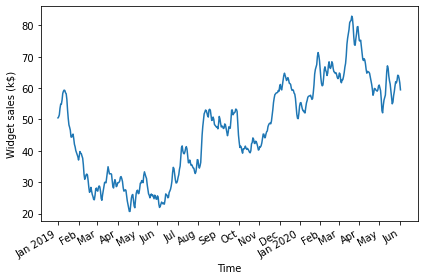

In [49]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Parece no ser estacionaria, pero igualmente lo chequeamos

In [50]:
ADF_result = adfuller(df['widget_sales'])
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -1.5121662069359045
p-value: 0.5274845352272606


El p-valor es alto, por tanto NO rechazamos la hipótesis nula de que la serie tiene una raíz unitaria. La serie no es estacionaria, requiere ser diferenciada.

Aplicamos transformación, diferencia de primer orden

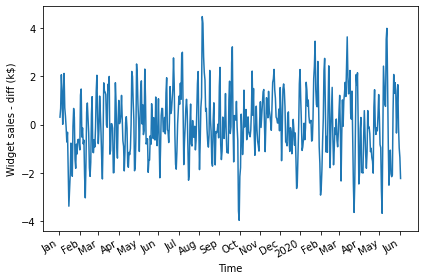

In [51]:
df["widget_sales_diff"] = df['widget_sales'].diff()
fig, ax = plt.subplots()

ax.plot(df["widget_sales_diff"])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Chequeamos si ahora tenemos una serie estacionaria y efectivamente lo es

In [52]:
ADF_result = adfuller(df['widget_sales_diff'].dropna())
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -10.576657780341959
p-value: 7.076922818587193e-19


Mejora 2026. No se trabaja sobre la serie diferenciada. Evitamos reconstrucción. Una vez que obtenemos la cantidad de veces que necesitamos diferenciar le pasamos el trabajo a la biblioteca Sarimax.

Entonces hay que diferenciar una vez:

In [53]:
d = 1

Ahora chequeamos autocorrelación, vemos que los coeficientes son significativos hasta el orden 2, por tanto tenemos un moving average process de orden 2, podemos usar entonces un modelo de MA de orden dos para realizar pronosticos sobre nuestra serie.

In [54]:
alpha = 0.05
acv = acf(df['widget_sales_diff'].dropna(), nlags=5, alpha=alpha)
acv[0]

array([ 1.        ,  0.60988516,  0.14099242, -0.03784949, -0.04582061,
        0.00697026])

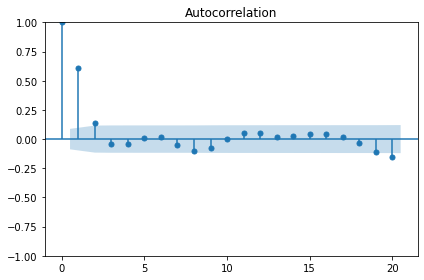

In [55]:
plot_acf(df['widget_sales_diff'].dropna(), lags=20, alpha=alpha)
plt.tight_layout()
plt.show()

In [56]:
df_train = df.iloc[:int(0.9*len(df))][["widget_sales"]]
df_test = df.iloc[int(0.9*len(df)):][["widget_sales"]]
print(len(df_train))
print(len(df_test))

450
50


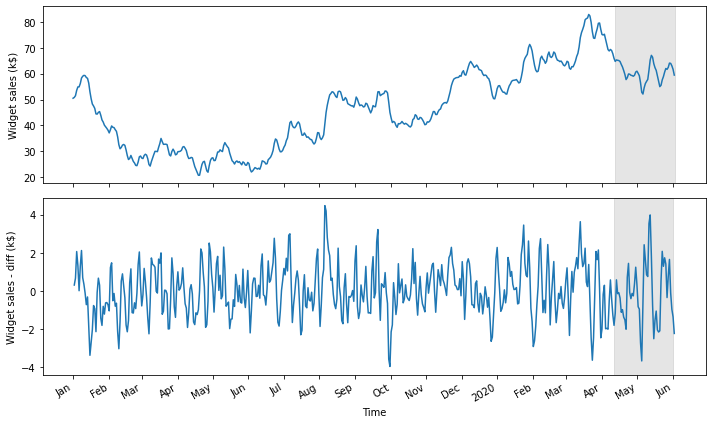

In [57]:
fig, (ax1, ax2) = plt.subplots(figsize=(10, 6), nrows=2, ncols=1, sharex=True)
ax1.plot(df['widget_sales'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color='#808080', alpha=0.2)
ax2.plot(df['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales - diff (k$)')
ax2.axvspan(449, 498, color='#808080', alpha=0.2)
plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [58]:
TRAIN_LEN   = len(df_train)
HORIZON     = len(df_test)
WINDOW      = 2


In [59]:
df_train["widget_sales"]

0      50.496714
1      50.805493
2      51.477758
3      53.542228
4      54.873108
         ...    
445    68.790650
446    69.368613
447    68.959573
448    67.709794
449    65.906136
Name: widget_sales, Length: 450, dtype: float64

In [60]:
def rolling_forecast(df=None, train_len=100, horizon=2, window=2, method='mean', p=None, q=None, d=None) -> list:
    total_len = train_len + horizon
    if method == 'mean':
        pred_mean = []        
        for i in range(train_len, total_len, window):
            mean = np.mean(df.iloc[:i])
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df.iloc[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value
    
    elif method == 'ARMA':
        pred_ARMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.iloc[:i], order=(p, d, q))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARMA.extend(oos_pred)
            
        return pred_ARMA

In [61]:
pred_mean           = rolling_forecast(df["widget_sales"], TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value     = rolling_forecast(df["widget_sales"], TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA             = rolling_forecast(df["widget_sales"], TRAIN_LEN, HORIZON, WINDOW, 'ARMA', p=0, d=d, q=2)

# Ensure predictions are lists
pred_mean = list(pred_mean)
pred_last_value = list(pred_last_value)
pred_MA = list(pred_MA)

# Helper to match df_test length
def _fit_len(preds, target_len, fill_value=np.nan):
    if len(preds) >= target_len:
        return preds[:target_len]
    else:
        return preds + [fill_value] * (target_len - len(preds))

pred_mean = _fit_len(pred_mean, len(df_test))
pred_last_value = _fit_len(pred_last_value, len(df_test))
pred_MA = _fit_len(pred_MA, len(df_test))

# Assign safely
df_test = df_test.copy()
df_test['pred_mean'] = pred_mean
df_test['pred_last_value'] = pred_last_value
df_test['pred_MA'] = pred_MA


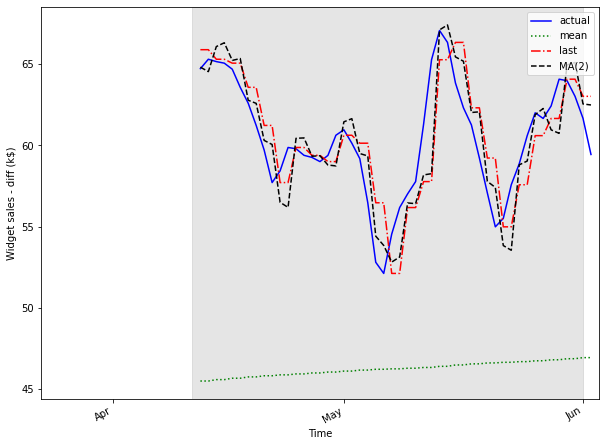

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(df_test['widget_sales'], 'b-', label='actual')
ax.plot(df_test['pred_mean'], 'g:', label='mean')
ax.plot(df_test['pred_last_value'], 'r-.', label='last')
ax.plot(df_test['pred_MA'], 'k--', label='MA(2)')

ax.legend(loc='upper right')

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

ax.axvspan(449, 498, color='#808080', alpha=0.2)

ax.set_xlim(449, 500)

plt.xticks(
    [439, 468, 498], 
    ['Apr', 'May', 'Jun'])

fig.autofmt_xdate()

plt.show()

Mejora 2026, compara resultados en escala original. 

¿Cual de los 3 métodos produjo el mejor resultado?